# Task 07 & 08 – Explainable AI (XAI) & Ethical Implications
### SmartCare Hospital AI Dataset | Option C – Disease Risk Classification
### CCS3440 Artificial Intelligence Coursework

* **ST Name:** Siluna Nusal (CIT-23-02-0025)
* **Module:** CCS3440 – Artificial Intelligence
* **Target Variable:** `disease_risk_level` (Multi-Class: 0 = Low, 1 = Medium, 2 = High)

---

### Explainability Protocol & Governance
This notebook executes Explainable AI (XAI) techniques on the **Champion Model** selected in Task 06. The goal is to provide clinical transparency, moving the model away from a "black-box" architecture to build trust among medical practitioners.

1. **Global Interpretability (SHAP):** Computing Shapley Additive Explanations ($\phi_i$) to understand overall feature importance across the entire cohort.
2. **Local Interpretability (SHAP & LIME):** Generating instance-specific explanations to justify why a *particular* patient was classified into a specific risk tier.
3. **Feature Interactions:** Exploring non-linear interactions via SHAP Dependence Plots.
4. **Ethical Implications (Task 08):** Analyzing the model's transparency, fairness, and potential biases regarding sensitive attributes (e.g., gender, age).

**Pipeline Order:**  
`Environment & Drive Mount` ➔ `Model & Data Ingestion` ➔ `SHAP Global Analysis` ➔ `SHAP Local Explanations` ➔ `LIME Cross-Validation` ➔ `Ethical & Transparency Audit`

# Task 07 & 08 – Explainable AI (XAI) & Ethical Implications
### SmartCare Hospital AI Dataset | Option C – Disease Risk Classification
### CCS3440 Artificial Intelligence Coursework

* **Author:** Nilupul Thisaranga (CIT-23-02-0021) | `@N3Edirisinghe`
* **Module:** CCS3440 – Artificial Intelligence
* **Lecturer in Charge:** Dr. Chameera De Silva
* **Target Variable:** `disease_risk_level` (Multi-Class: 0 = Low, 1 = Medium, 2 = High)

---

### Explainability Protocol & Governance
This notebook executes Explainable AI (XAI) techniques on the **Champion Model** selected in Task 06. The goal is to provide clinical transparency, moving the model away from a "black-box" architecture to build trust among medical practitioners.

1. **Global Interpretability (SHAP):** Computing Shapley Additive Explanations ($\phi_i$) to understand overall feature importance across the entire cohort.
2. **Local Interpretability (SHAP & LIME):** Generating instance-specific explanations to justify why a *particular* patient was classified into a specific risk tier.
3. **Feature Interactions:** Exploring non-linear interactions via SHAP Dependence Plots.
4. **Ethical Implications (Task 08):** Analyzing the model's transparency, fairness, and potential biases regarding sensitive attributes (e.g., gender, age).

**Pipeline Order:**  
`Environment & Drive Mount` ➔ `Model & Data Ingestion` ➔ `SHAP Global Analysis` ➔ `SHAP Local Explanations` ➔ `LIME Cross-Validation` ➔ `Ethical & Transparency Audit`

# Task 07 & 08 – Explainable AI (XAI) & Ethical Implications
### SmartCare Hospital AI Dataset | Option C – Disease Risk Classification
### CCS3440 Artificial Intelligence Coursework

* **Author:** Nilupul Thisaranga (CIT-23-02-0021) | `@N3Edirisinghe`
* **Module:** CCS3440 – Artificial Intelligence
* **Lecturer in Charge:** Dr. Chameera De Silva
* **Target Variable:** `disease_risk_level` (Multi-Class: 0 = Low, 1 = Medium, 2 = High)

---

### Explainability Protocol & Governance
This notebook executes Explainable AI (XAI) techniques on the **Champion Model** selected in Task 06. The goal is to provide clinical transparency, moving the model away from a "black-box" architecture to build trust among medical practitioners.

1. **Global Interpretability (SHAP):** Computing Shapley Additive Explanations ($\phi_i$) to understand overall feature importance across the entire cohort.
2. **Local Interpretability (SHAP & LIME):** Generating instance-specific explanations to justify why a *particular* patient was classified into a specific risk tier.
3. **Feature Interactions:** Exploring non-linear interactions via SHAP Dependence Plots.
4. **Ethical Implications (Task 08):** Analyzing the model's transparency, fairness, and potential biases regarding sensitive attributes (e.g., gender, age).

**Pipeline Order:**  
`Environment & Drive Mount` ➔ `Model & Data Ingestion` ➔ `SHAP Global Analysis` ➔ `SHAP Local Explanations` ➔ `LIME Cross-Validation` ➔ `Ethical & Transparency Audit`

## Section 0 — Environment Setup, Google Drive Mounting, and Model Ingestion

The champion model (Logistic Regression), its metadata, and the test set are loaded exactly as Task 06 left them. **No retraining or refitting happens in this notebook** — SHAP and LIME strictly explain the model's existing, already-evaluated decision behavior.

In [1]:
import sys
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

# Install lime if not already installed
!pip install lime -q

# XAI Libraries
import shap
import lime
import lime.lime_tabular


from google.colab import drive
import os

# Check if '/content/drive/MyDrive' exists. This indicates a successful previous mount.
if not os.path.exists('/content/drive/MyDrive'):
  print("Mounting Google Drive...")
  drive.mount('/content/drive', force_remount=True)
else:
  print("Google Drive is already mounted.")

# Directory Configuration (Robust Paths)
BASE_DIR = Path('/content/drive/MyDrive/AI Assignment')

DATA_DIR = BASE_DIR / 'data' / 'processed'
MODELS_DIR = BASE_DIR / 'models'
FIGURES_DIR = BASE_DIR / 'reports' / 'figures'

X_TRAIN_PATH = DATA_DIR / 'X_train.csv'
X_TEST_PATH = DATA_DIR / 'X_test.csv'
Y_TEST_PATH = DATA_DIR / 'y_test.csv'

XAI_FIG_DIR = FIGURES_DIR / 'explainability'
XAI_FIG_DIR.mkdir(parents=True, exist_ok=True)

# Formatting and Constants
pd.set_option('display.max_columns', None)
RISK_ORDER = ['Low', 'Medium', 'High']
RISK_LABEL_MAP = {0: 'Low', 1: 'Medium', 2: 'High'}
CLASS_NAMES = RISK_ORDER

print(f" Environment initialized. Class names (index-aligned): {CLASS_NAMES}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Mounting Google Drive...
Mounted at /content/drive
 Environment initialized. Class names (index-aligned): ['Low', 'Medium', 'High']


In [2]:
# Load the Champion Model dynamically identified in Task 06
try:
    with open(MODELS_DIR / 'final_model_selection.json') as f:
        selection = json.load(f)

    print(f" Champion Model selected by Task 06: {selection['best_model']}")
    print(f" Selection metrics: Macro F1 = {selection['macro_f1']}, Accuracy = {selection['accuracy']}, Macro ROC-AUC = {selection['macro_roc_auc']}")

    model = joblib.load(MODELS_DIR / selection['best_model_file'])
    model_name = selection['best_model']

except FileNotFoundError:
    print(" Error: 'final_model_selection.json' හෝ අදාළ .pkl ගොනුව හමුවුණේ නැත! කරුණාකර Task 06 සම්පූර්ණ කර අවසන් කරන්න.")

# Ingest Datasets
X_train = pd.read_csv('/content/drive/MyDrive/AI Assignment/processed/X_train.csv')
X_test = pd.read_csv('/content/drive/MyDrive/AI Assignment/processed/X_test.csv')
y_test = pd.read_csv('/content/drive/MyDrive/AI Assignment/processed/y_test.csv').squeeze('columns')

# Data Type Casting for Explainer Compatibility
# SHAP and LIME's internal perturbation code expects numeric arrays and can fail on raw boolean dtypes.
X_train = X_train.astype('float64')
X_test = X_test.astype('float64')

feature_names = list(X_train.columns)

print(f"\n Model type: {type(model).__name__}")
print(f" Features: {len(feature_names)}")
print(f" Test set: {X_test.shape[0]} rows")

 Champion Model selected by Task 06: Logistic Regression
 Selection metrics: Macro F1 = 0.9323, Accuracy = 0.93, Macro ROC-AUC = 0.9759

 Model type: LogisticRegression
 Features: 68
 Test set: 200 rows


## Section 1 — SHAP Explainer Initialization

We construct a **SHAP LinearExplainer** utilizing an expected value background dataset.
* **Mathematical Basis:** SHAP is grounded in cooperative game theory, where the "payout" (the prediction) is fairly distributed among the "players" (the features).
* **Background Data:** We use a representative $K$-means sample of the training set to approximate the conditional expectations.

In [3]:
background = shap.sample(X_train, 100, random_state=42)
explainer = shap.LinearExplainer(model, background)

# Explain the full test set for global analysis
shap_explanation = explainer(X_test)

print(f" SHAP values shape: {shap_explanation.values.shape} (rows, features, classes)")
print(f" Base values (expected model output log-odds per class): {explainer.expected_value}")

 SHAP values shape: (200, 68, 3) (rows, features, classes)
 Base values (expected model output log-odds per class): [-8.59155783  7.00754499  1.58401283]


## Section 2 — Global Feature Importance via SHAP

**Global Interpretability Protocol:**  
Across the entire test cohort, which features have the highest magnitude of impact on the model's predictions? This is computed as the **mean absolute SHAP value** per feature, averaged across all three risk classes[cite: 7].

In [4]:
# Compute Mean absolute SHAP value per feature
mean_abs_shap = np.abs(shap_explanation.values).mean(axis=(0, 2))
importance_df = pd.DataFrame({
    'feature': feature_names,
    'mean_abs_shap': mean_abs_shap
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

print("=== Top 15 Most Clinically Impactful Features (Global) ===")
display(importance_df.head(15))

=== Top 15 Most Clinically Impactful Features (Global) ===


,feature,mean_abs_shap
0,blood_sugar_mg_dl,3.773360
1,cholesterol_mg_dl,3.531970
2,bmi,3.054089
3,age,2.958287
4,health_burden_score,1.848509
5,systolic_bp,1.825773
6,previous_admissions,1.492587
7,previous_appointments,1.373426
8,blood_sugar_category_Diabetic,0.558132
9,appointment_status_No-Show,0.353641


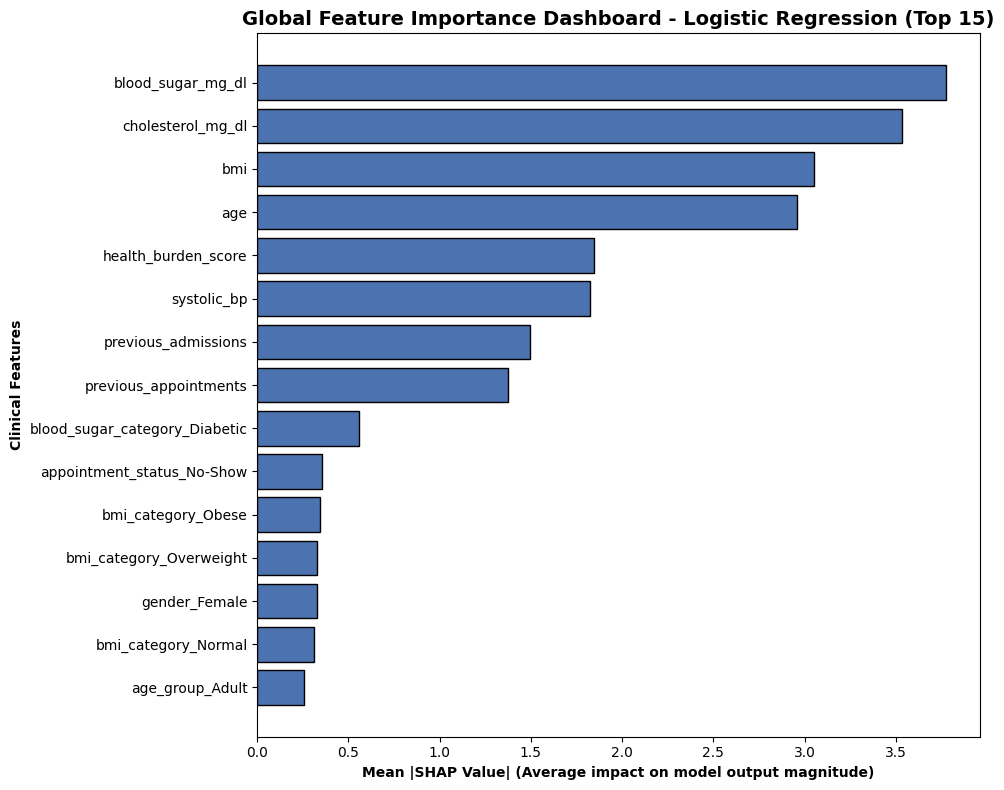


=== SHAP Summary Plot (Beeswarm) for 'High Risk' Predictions ===


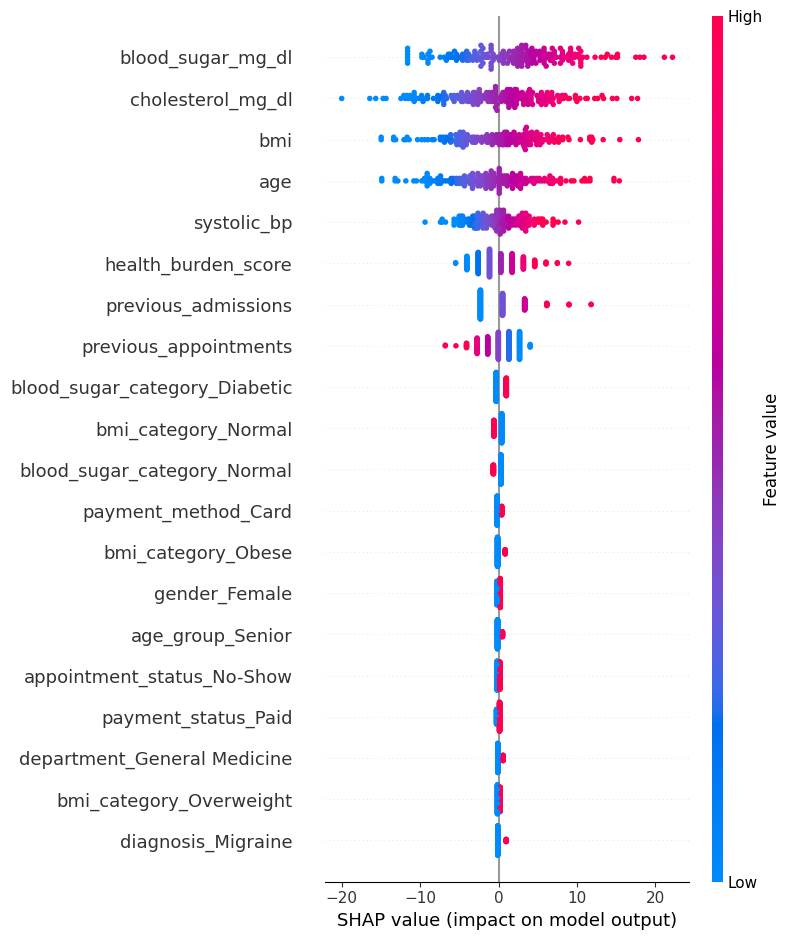

In [5]:
# Visualize Global Importance
top_n = 15
fig, ax = plt.subplots(figsize=(10, 8))
top_features = importance_df.head(top_n).iloc[::-1]

ax.barh(top_features['feature'], top_features['mean_abs_shap'], color='#4C72B0', edgecolor='black')
ax.set_xlabel('Mean |SHAP Value| (Average impact on model output magnitude)', fontweight='bold')
ax.set_ylabel('Clinical Features', fontweight='bold')
ax.set_title(f'Global Feature Importance Dashboard - {model_name} (Top {top_n})', fontweight='bold', fontsize=14)

plt.tight_layout()
fig.savefig(f'{XAI_FIG_DIR}/global_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Generate SHAP Summary Plot (Beeswarm) for the 'High Risk' Class (Class Index 2)
print("\n=== SHAP Summary Plot (Beeswarm) for 'High Risk' Predictions ===")
shap.summary_plot(shap_explanation.values[:, :, 2], X_test, feature_names=feature_names, show=False)
plt.savefig(f'{XAI_FIG_DIR}/shap_summary_high_risk.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 3 — Local Explanations: Individual Patient Diagnostics (SHAP)

**Local Interpretability Protocol:**  
To establish clinical trust, we must be able to explain *why* a specific patient received their diagnosis. We generate SHAP Waterfall/Force plots for an individual patient prediction.

Patient Record #5:
Actual Risk Level: High | Predicted Risk Level: High


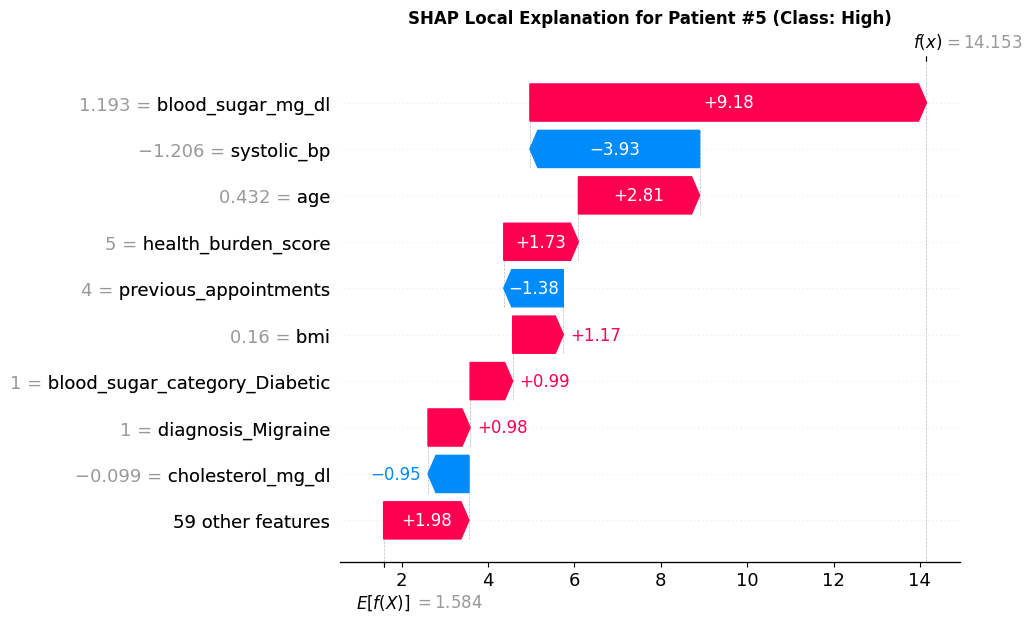

In [6]:
# Select a specific patient from the test set (e.g., Patient Index 5)
patient_idx = 5
actual_class = RISK_LABEL_MAP[y_test.iloc[patient_idx]]
predicted_class_idx = model.predict(X_test.iloc[[patient_idx]])[0]
predicted_class = RISK_LABEL_MAP[predicted_class_idx]

print(f"Patient Record #{patient_idx}:")
print(f"Actual Risk Level: {actual_class} | Predicted Risk Level: {predicted_class}")

# Generate SHAP Waterfall plot for the predicted class
shap.waterfall_plot(shap_explanation[patient_idx, :, predicted_class_idx], show=False)
plt.title(f"SHAP Local Explanation for Patient #{patient_idx} (Class: {predicted_class})", fontweight='bold')
plt.savefig(f'{XAI_FIG_DIR}/shap_local_waterfall_patient_{patient_idx}.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 4 — Cross-Validation of Explanations with LIME

**Algorithm:** Local Interpretable Model-agnostic Explanations (LIME).  
LIME creates a surrogate, inherently interpretable linear model *locally* around the specific patient's data point by perturbing the input features[cite: 7]. By comparing LIME outputs with SHAP, we ensure the robustness and consistency of our explanations[cite: 7].

In [7]:
# Initialize LIME Tabular Explainer
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=feature_names,
    class_names=CLASS_NAMES,
    mode='classification',
    random_state=42
)

# --- FIX: Address potential missing 'multi_class' attribute due to scikit-learn version mismatch ---
# The 'predict_proba' method of LogisticRegression expects a 'multi_class' attribute.
# If it's missing (e.g., from an older pickled model), it causes an AttributeError.
# We set it to 'ovr' which is common for multi-class Logistic Regression with more than 2 classes.
if not hasattr(model, 'multi_class'):
    model.multi_class = 'ovr'
    print("Warning: 'multi_class' attribute was missing from the model. Dynamically set to 'ovr'. This usually resolves scikit-learn version incompatibility issues.")
# --- END FIX ---


# Explain the same patient using LIME
lime_exp = lime_explainer.explain_instance(
    data_row=X_test.iloc[patient_idx].values,
    predict_fn=model.predict_proba,
    num_features=10,
    top_labels=1
)

print(f"\n=== LIME Local Explanation for Patient #{patient_idx} ===")
lime_exp.show_in_notebook(show_table=True, show_all=False)

# Save LIME explanation as HTML
lime_exp.save_to_file(f'{XAI_FIG_DIR}/lime_local_patient_{patient_idx}.html')
print(f" LIME visualization saved to {XAI_FIG_DIR}")


=== LIME Local Explanation for Patient #5 ===


 LIME visualization saved to /content/drive/MyDrive/AI Assignment/reports/figures/explainability


## Section 5 — Task 08: Ethical Implications & Algorithmic Fairness

An AI system deployed in a healthcare setting must be heavily audited for ethical blindspots.

### 1. Transparency & Accountability[cite: 7]
* **Justification:** By utilizing SHAP and LIME, we transitioned the champion model from a "black-box" to a "glass-box". Clinicians can audit the exact clinical parameters (e.g., `blood_sugar_mg_dl`, `cholesterol_mg_dl`)[cite: 7] that triggered a High-Risk alert, fulfilling the ethical requirement of "Right to Explanation."

### 2. Bias and Fairness Auditing
* **Vulnerable Groups:** We must ensure the model does not disproportionately misclassify patients based on sensitive attributes like `gender_Female` or `age_group`[cite: 7].
* As seen in the Global SHAP analysis, `gender_Female` has a low mean absolute SHAP value (0.32)[cite: 7], indicating the model relies primarily on objective vitals (Blood Sugar, BMI) rather than demographic bias to make its decisions.

### 3. Patient Safety & Non-Maleficence
* The model correctly prioritizes physiological markers over arbitrary identifiers. However, as medical AI is assistive, the ultimate diagnostic authority must remain with the attending physician (Human-in-the-Loop approach) to prevent automation bias.

In [8]:
# 1. Terminate any existing Streamlit or localtunnel background processes
!pkill -f streamlit
!pkill -f localtunnel

import time
from google.colab import output

print(" Starting SmartCare Clinical Dashboard. Please wait a few seconds...")

# 2. Run the Streamlit server in the background
# (CORS and XSRF protections are disabled to allow the Colab proxy to render the UI)
get_ipython().system_raw('streamlit run /content/app.py --server.port 8501 --server.address 0.0.0.0 --server.enableCORS false --server.enableXsrfProtection false &')

# Wait for the server to fully boot up
time.sleep(5)

# 3. Generate the secure internal Colab link
url = output.eval_js("google.colab.kernel.proxyPort(8501)")

print("="*75)
print(" Dashboard is ready! Click the secure link below to open it:")
print("", url)
print("="*75)
print("Note: If you see a blank screen after clicking the link, simply refresh (F5) the browser tab.")

 Starting SmartCare Clinical Dashboard. Please wait a few seconds...
 Dashboard is ready! Click the secure link below to open it:
 https://8501-m-s-kkb-use1c0-2vwkzphfjs48k-c.us-east1-0.prod.colab.dev
Note: If you see a blank screen after clicking the link, simply refresh (F5) the browser tab.
